In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score, adjusted_rand_score
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.optimizers import Adam


# Réseau de Neuronne MLP

## Visualisation du jeu de données simples (4 classes)

In [3]:
df = pd.read_csv("data_global_simple.csv", sep=';')
a=df.columns
df

,Joueur,Nation,Pos,Équipe,Âge,Naissance,MJ,Titulaire,Min,90,...,Balle au pied,TotDist.1,DistBut.1,PrgC.1,1/3.1,CSR,Manqué,Perte,Rec,PrgR.1
0,Brenden Aaronson,us USA,MT,Leeds United,21.0,2000.0,36.0,28.0,2372.0,26.4,...,26.0,138.1,58.0,1.63,1.29,0.49,2.69,3.11,29.1,5.72
1,Paxten Aaronson,us USA,MT,Eint Frankfurt,18.0,2003.0,7.0,0.0,173.0,1.9,...,28.9,165.3,75.3,4.21,1.05,1.05,2.63,1.05,34.2,7.89
2,James Abankwah,ie IRL,DF,Udinese,18.0,2004.0,2.0,1.0,63.0,0.7,...,25.7,68.6,27.1,0.00,0.00,0.00,1.43,1.43,30.0,0.00
3,George Abbott,eng ENG,MT,Tottenham,16.0,2005.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,1.0,0.00
4,Yunis Abdelhamid,ma MAR,DF,Reims,34.0,1987.0,37.0,37.0,0.0,37.0,...,46.6,293.8,165.5,1.08,0.57,0.08,0.73,0.62,40.5,0.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6348,Charlie Wyke,eng ENG,AT,Wigan Athletic,29.0,1992.0,18.0,8.0,777.0,8.6,...,137.0,404.0,114.0,3.00,3.00,2.00,29.00,11.00,209.0,49.00
6349,Jerry Yates,eng ENG,AT,Blackpool,25.0,1996.0,41.0,39.0,0.0,37.4,...,625.0,2888.0,1101.0,31.00,25.00,16.00,90.00,56.00,751.0,202.00
6350,Andy Yiadom,gh GHA,DF,Reading,30.0,1991.0,41.0,41.0,3554.0,39.5,...,1012.0,5552.0,2790.0,55.00,37.00,8.00,42.00,36.00,1123.0,101.00
6351,Okay Yokuşlu,tr TUR,MT,West Brom,28.0,1994.0,38.0,34.0,2871.0,31.9,...,925.0,4336.0,1989.0,21.00,30.00,2.00,41.00,32.00,1105.0,30.00


<Axes: xlabel='Pos', ylabel='Buts'>

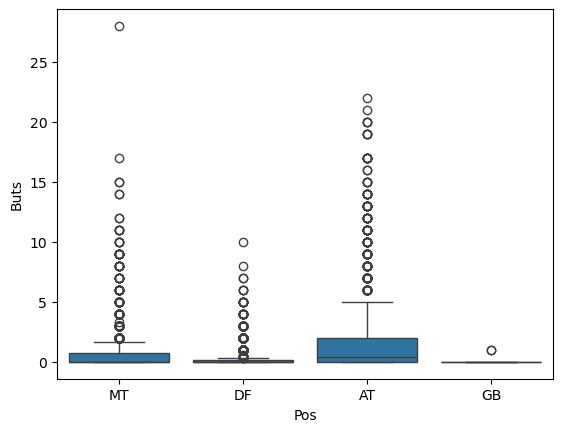

In [4]:
sns.boxplot(x='Pos', y='Buts', data=df)


<Axes: xlabel='Pos'>

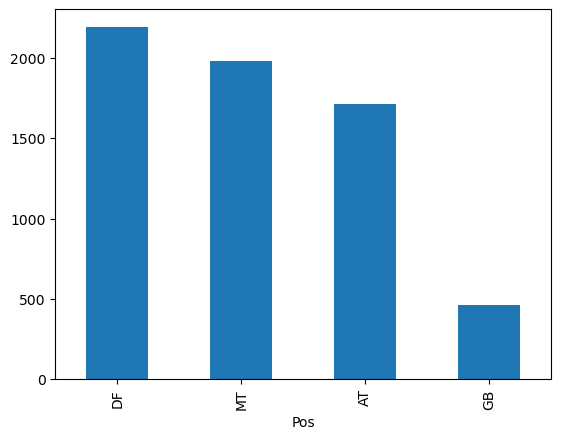

In [5]:
df['Pos'].value_counts().plot(kind='bar')


## Visualisation jeu donnée complets

In [7]:
df2 = pd.read_csv("data_global.csv", sep=';')
a=df2.columns
df2

,Joueur,Nation,Pos,Équipe,Âge,Naissance,MJ,Titulaire,Min,90,...,Balle au pied,TotDist.1,DistBut.1,PrgC.1,1/3.1,CSR,Manqué,Perte,Rec,PrgR.1
0,Brenden Aaronson,us USA,"MT,AT",Leeds United,21.0,2000.0,36.0,28.0,2372.0,26.4,...,26.0,138.1,58.0,1.63,1.29,0.49,2.69,3.11,29.1,5.72
1,Paxten Aaronson,us USA,"MT,DF",Eint Frankfurt,18.0,2003.0,7.0,0.0,173.0,1.9,...,28.9,165.3,75.3,4.21,1.05,1.05,2.63,1.05,34.2,7.89
2,James Abankwah,ie IRL,DF,Udinese,18.0,2004.0,2.0,1.0,63.0,0.7,...,25.7,68.6,27.1,0.00,0.00,0.00,1.43,1.43,30.0,0.00
3,George Abbott,eng ENG,MT,Tottenham,16.0,2005.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,1.0,0.00
4,Yunis Abdelhamid,ma MAR,DF,Reims,34.0,1987.0,37.0,37.0,0.0,37.0,...,46.6,293.8,165.5,1.08,0.57,0.08,0.73,0.62,40.5,0.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6348,Charlie Wyke,eng ENG,AT,Wigan Athletic,29.0,1992.0,18.0,8.0,777.0,8.6,...,137.0,404.0,114.0,3.00,3.00,2.00,29.00,11.00,209.0,49.00
6349,Jerry Yates,eng ENG,AT,Blackpool,25.0,1996.0,41.0,39.0,0.0,37.4,...,625.0,2888.0,1101.0,31.00,25.00,16.00,90.00,56.00,751.0,202.00
6350,Andy Yiadom,gh GHA,DF,Reading,30.0,1991.0,41.0,41.0,3554.0,39.5,...,1012.0,5552.0,2790.0,55.00,37.00,8.00,42.00,36.00,1123.0,101.00
6351,Okay Yokuşlu,tr TUR,MT,West Brom,28.0,1994.0,38.0,34.0,2871.0,31.9,...,925.0,4336.0,1989.0,21.00,30.00,2.00,41.00,32.00,1105.0,30.00


<Axes: xlabel='Pos', ylabel='Buts'>

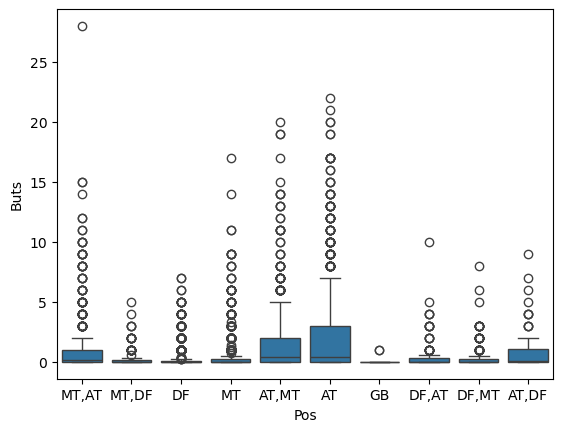

In [8]:
sns.boxplot(x='Pos', y='Buts', data=df2)


<Axes: xlabel='Pos'>

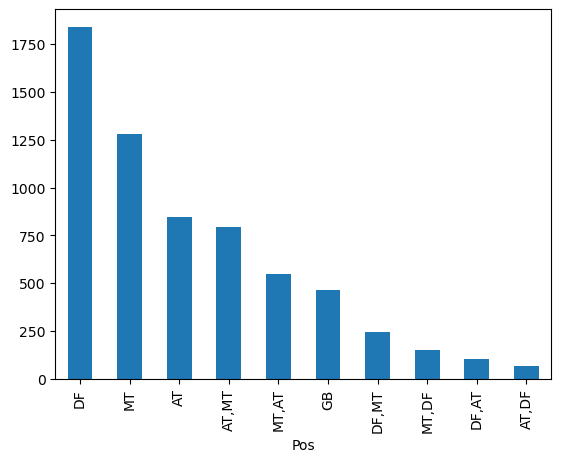

In [9]:
df2['Pos'].value_counts().plot(kind='bar')


## Modèle MLP pour 4 classes

### Séparation en données de test/entraineemnt 

In [10]:
X = df.select_dtypes(include=["number"]).dropna()
y = df.loc[X.index, "Pos"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Séparation des données en train et test
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


### Réseau 1 (1 couche avec 4 neurones : sigmoid)

In [11]:
model = models.Sequential([
    layers.Input(shape=(X_train_simple.shape[1],)),
    layers.Dense(4, activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │           628 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628 (2.45 KB)

 Trainable params: 628 (2.45 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history = model.fit(
    X_train_simple, y_train_simple,
    validation_data=(X_test_simple, y_test_simple),
    epochs=100,
    batch_size=32
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3324 - loss: 78670.0547 - val_accuracy: 0.4115 - val_loss: 82286.0078
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4359 - loss: 43523.9023 - val_accuracy: 0.3131 - val_loss: 40249.4180
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4600 - loss: 29501.0918 - val_accuracy: 0.4532 - val_loss: 35864.7070
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4776 - loss: 29033.4961 - val_accuracy: 0.5924 - val_loss: 14576.7188
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4640 - loss: 26691.4414 - val_accuracy: 0.5035 - val_loss: 11007.6348
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5044 - loss: 23960.4141 - val_accuracy: 0.4886 - val_loss: 19184.8965
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5003 - loss: 18685.4941 - val_accuracy: 0.4367 - val_loss: 7701.8086
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0

In [13]:
test_loss, test_acc = model.evaluate(X_test_simple, y_test_simple)
print(f"Test accuracy: {test_acc:.2f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4950 - loss: 4188.8525 
Test accuracy: 0.51


Test accuracy: 0.51


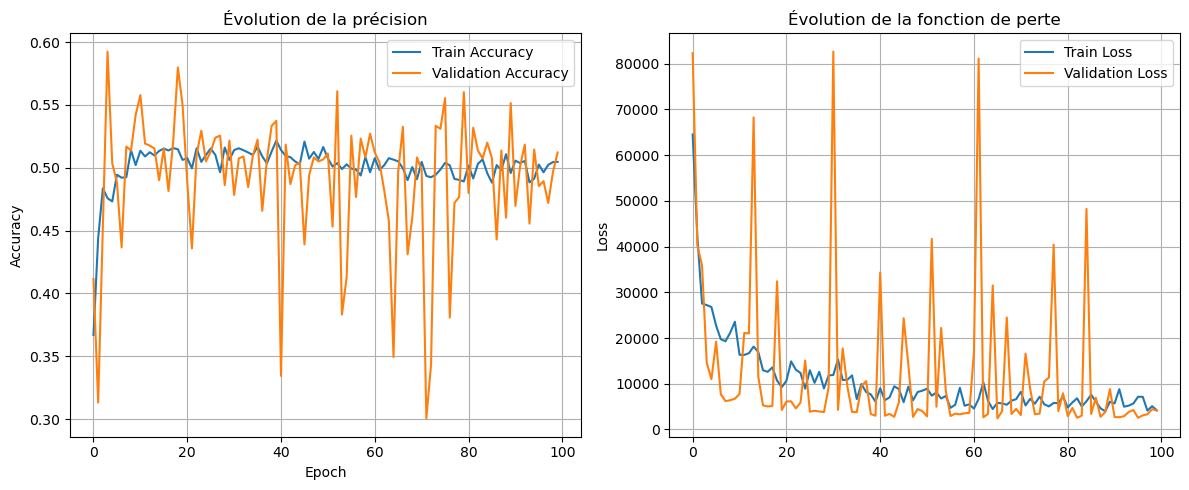

In [14]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de la précision")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
print(f"Test accuracy: {test_acc:.2f}")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Pour ce modèle, on a une couche avec 4 neurones pour les 4 classes et la fonction d’activation sigmoid (pour faire de la différenciation multiclasse). On remarque une précision très moyenne et une fonction de perte aléatoire qui ne diminue pas assez. Le modèle est trop simple et ne réussit pas à apprendre. On voit donc bien que la précision ne se stabilise pas, tout comme la fonction de perte.

### Réseau 2 (1 couche + 1 couche cachée : 4 neurones et sigmoid)

In [15]:
model2 = models.Sequential([
    layers.Input(shape=(X_train_simple.shape[1],)), 
    layers.Dense(4, activation='sigmoid'),
    layers.Dense(4, activation='softmax')
])
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 4)              │           628 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648 (2.53 KB)

 Trainable params: 648 (2.53 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model2.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',  # car les labels sont des entiers
    metrics=['accuracy']
)

history = model2.fit(
    X_train_simple, y_train_simple,
    validation_data=(X_test_simple, y_test_simple),
    epochs=100,
    batch_size=32
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3136 - loss: 1.3505 - val_accuracy: 0.3076 - val_loss: 1.2981
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3058 - loss: 1.2925 - val_accuracy: 0.3100 - val_loss: 1.2878
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3185 - loss: 1.2779 - val_accuracy: 0.3116 - val_loss: 1.2802
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3190 - loss: 1.2858 - val_accuracy: 0.3454 - val_loss: 1.2754
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3456 - loss: 1.2774 - val_accuracy: 0.3454 - val_loss: 1.2746
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3440 - loss: 1.2705 - val_accuracy: 0.3454 - val_loss: 1.2744
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3546 - loss: 1.2701 - val_accuracy: 0.3454 - val_loss: 1.2742
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3487 - loss: 1.2702 - val_accu

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3219 - loss: 1.3045
Test accuracy: 0.35
Test accuracy: 0.35


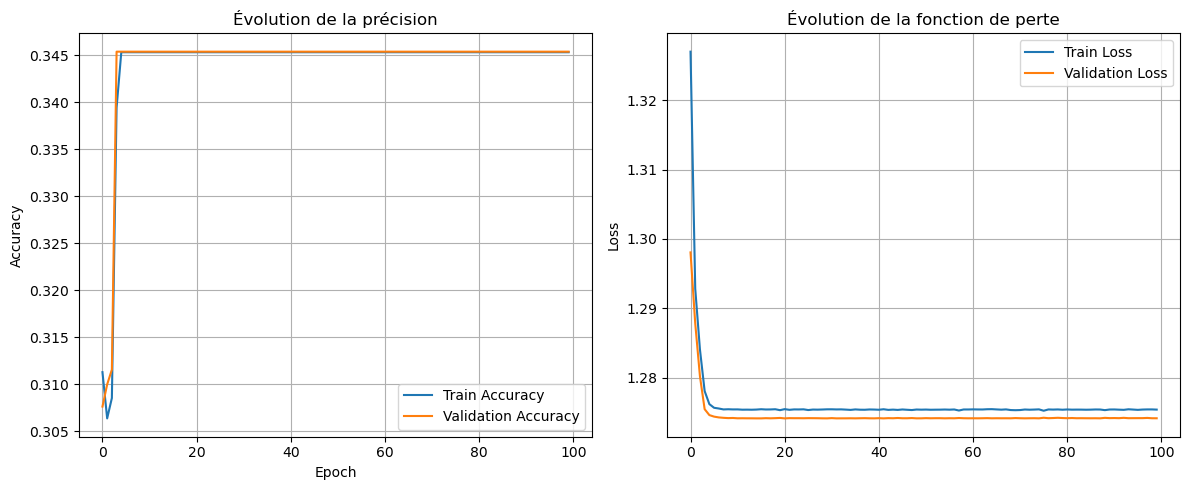

In [17]:
test_loss, test_acc = model2.evaluate(X_test_simple, y_test_simple)
print(f"Test accuracy: {test_acc:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de la précision")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
print(f"Test accuracy: {test_acc:.2f}")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Le résultat n'est pas meilleur qu'avec le premier modèle mais on remarque qu'il progresse réellement et que la fonction de perte diminue. Le modèle 2 n'apprend pas bien, cela peut être du à un manque de neurones ou une fonction d'activation qui ne correspond pas à ce que l'on veut faire.

### Réseau 3 (1 couche + 1 couche cachée : 4 neurones et relu)

In [18]:
model3 = models.Sequential([
    layers.Input(shape=(X_train_simple.shape[1],)), 
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax') 
    
])
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,260 (47.89 KB)

 Trainable params: 12,260 (47.89 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model3.compile(
    optimizer='sgd',
    loss='SparseCategoricalCrossentropy',
    metrics=['accuracy']
)

history = model3.fit(
    X_train_simple, y_train_simple,
    validation_data=(X_test_simple, y_test_simple),
    epochs=100,
    batch_size=32
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3093 - loss: 305327464195268336272015360.0000 - val_accuracy: 0.3454 - val_loss: 1.3370
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3408 - loss: 1.3317 - val_accuracy: 0.3454 - val_loss: 1.3110
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3457 - loss: 1.3089 - val_accuracy: 0.3454 - val_loss: 1.2970
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3508 - loss: 1.2973 - val_accuracy: 0.3454 - val_loss: 1.2888
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3341 - loss: 1.2864 - val_accuracy: 0.3454 - val_loss: 1.2838
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3479 - loss: 1.2818 - val_accuracy: 0.3454 - val_loss: 1.2805
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3372 - loss: 1.2802 - val_accuracy: 0.3454 - val_loss: 1.2784
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3450

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3219 - loss: 1.3035
Test accuracy: 0.35
Test accuracy: 0.35


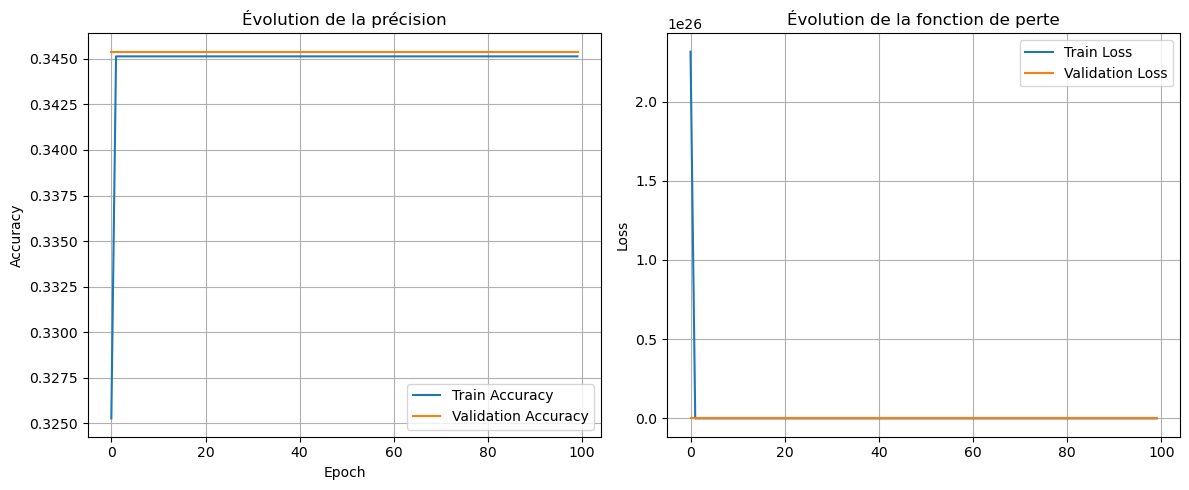

In [20]:
test_loss, test_acc = model3.evaluate(X_test_simple, y_test_simple)
print(f"Test accuracy: {test_acc:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de la précision")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
print(f"Test accuracy: {test_acc:.2f}")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Le modèle 3 malgré une modification de la fonction d'activation ou de la fontion de perte du nombre de neurones sur les couches n'est pas concluant : on va esssayer d'ajouter des couches en plus. De plus, on peut également penser à normaliser les données afin de donner une influence équitable à toutes les statistiques

### Réseau 4 (Normalisation + augmentation des couches et nombre de neuronne) 

In [21]:
# On sélectionne les colonnes ave des valeurs numériques e ton suprime les autres 
X = df.select_dtypes(include=["number"]).dropna()

y = df.loc[X.index, "Pos"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# On séparation en train et test
X_train2_simple, X_test2_simple, y_train2_simple, y_test2_simple = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# On normalise les données
scaler = StandardScaler()
X_train_scaled_simple = scaler.fit_transform(X_train2_simple)
X_test_scaled_simple = scaler.transform(X_test2_simple)


In [22]:
model4 = models.Sequential([
    layers.Input(shape=(X_train_scaled_simple.shape[1],)),  # entrée = nb de features
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax') 
    
])
model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,612 (111.77 KB)

 Trainable params: 28,612 (111.77 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model4.compile(
    optimizer='sgd',
    loss='SparseCategoricalCrossentropy', 
    metrics=['accuracy']
)

history = model4.fit(
    X_train_scaled_simple, y_train2_simple,
    validation_data=(X_test_scaled_simple, y_test2_simple),
    epochs=100,
    batch_size=32
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5501 - loss: 1.1087 - val_accuracy: 0.7238 - val_loss: 0.7747
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7529 - loss: 0.7029 - val_accuracy: 0.7663 - val_loss: 0.6312
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7942 - loss: 0.5708 - val_accuracy: 0.7766 - val_loss: 0.5675
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.5062 - val_accuracy: 0.7758 - val_loss: 0.5321
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8110 - loss: 0.4889 - val_accuracy: 0.7946 - val_loss: 0.5054
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8191 - loss: 0.4660 - val_accuracy: 0.7962 - val_loss: 0.4917
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8249 - loss: 0.4363 - val_accuracy: 0.7962 - val_loss: 0.4966
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8364 - loss: 0.4091 - val_accu

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4249 - loss: 3882.4302
Test accuracy: 0.46
Test accuracy: 0.46


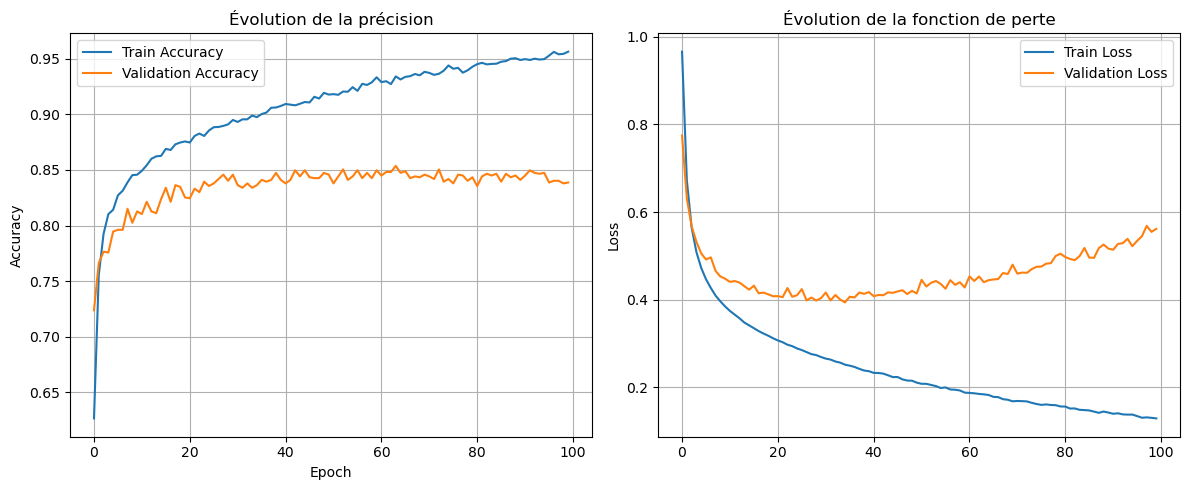

In [24]:
test_loss, test_acc = model4.evaluate(X_test2_simple, y_test2_simple)
print(f"Test accuracy: {test_acc:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de la précision")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
print(f"Test accuracy: {test_acc:.2f}")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Une fois la normalisation réalisée qui permet de mieux équilibrer les données en entrées, on arrive à avoir un réel apprentissage. On remarque toutes fois que l'on est dans un cas de surapprentissage. On remarque que pour les données de validation (en orange), la perte diminue au début avant de remonter. Cela traduit un surentrainement du modèle : il s'adapte trop bien aux données d'entrainement dans le détail et ne parvient pas à représenter l'aspect général et donc à s'adapter et à prédire correctement sur des données qu'l n'a jamais vu. Cet écart du au suraprentissage peut se voir aussi sur la précision (le gap entre les deux courbes). 

### Réseau 5 (Réduction du nombre de neurones)

In [25]:
model5 = models.Sequential([
    layers.Input(shape=(X_train_scaled_simple.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='softmax') 
    
])
model5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │         2,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,684 (10.48 KB)

 Trainable params: 2,684 (10.48 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model5.compile(
    optimizer='sgd',
    loss='SparseCategoricalCrossentropy',
    metrics=['accuracy']
)

history = model5.fit(
    X_train_scaled_simple, y_train2_simple,
    validation_data=(X_test_scaled_simple, y_test2_simple),
    epochs=100,
    batch_size=32
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3623 - loss: 1.3530 - val_accuracy: 0.5334 - val_loss: 1.1461
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5776 - loss: 1.0751 - val_accuracy: 0.6247 - val_loss: 0.9772
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6536 - loss: 0.9052 - val_accuracy: 0.6562 - val_loss: 0.8256
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7003 - loss: 0.7611 - val_accuracy: 0.6876 - val_loss: 0.7383
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7305 - loss: 0.6760 - val_accuracy: 0.7026 - val_loss: 0.6807
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7313 - loss: 0.6406 - val_accuracy: 0.7168 - val_loss: 0.6436
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7604 - loss: 0.5845 - val_accuracy: 0.7372 - val_loss: 0.6146
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7721 - loss: 0.5563 - val_accu

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8641 - loss: 0.3769 
Test accuracy: 0.87
Test accuracy: 0.87


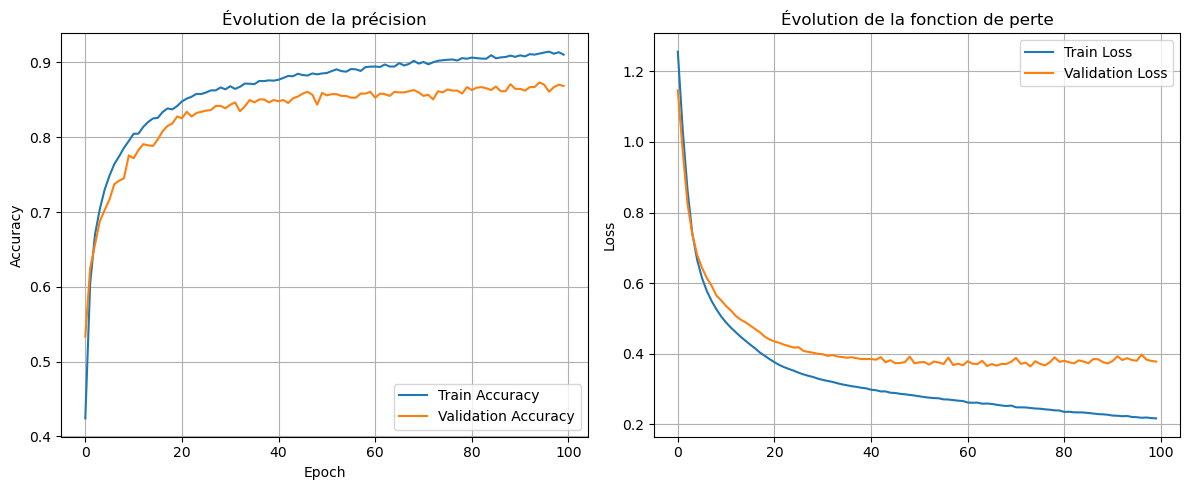

In [27]:
test_loss, test_acc = model5.evaluate(X_test_scaled_simple, y_test2_simple)
print(f"Test accuracy: {test_acc:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de la précision")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
print(f"Test accuracy: {test_acc:.2f}")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


En réduisant le nombre de neurones, on observe que l'on limite le surapprentissage, ce qui nous permet d'avoir des résultats assez satisfaisants. Néanmoins, on constate qu'il est toujours présent, et on va chercher à corriger cela en ajoutant des dropouts.

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


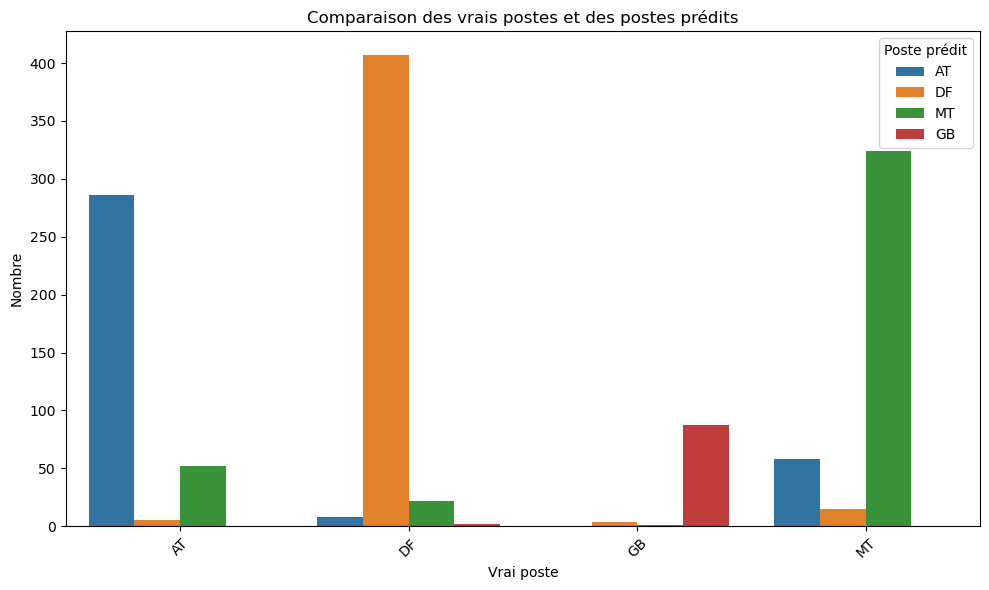

In [28]:
#1 Génération des prédictions
y_pred_probs = model5.predict(X_test_scaled_simple)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true_labels = label_encoder.inverse_transform(y_test2_simple)
y_pred_labels = label_encoder.inverse_transform(y_pred)

df_results = pd.DataFrame({
    "Vrai poste": y_true_labels,
    "Poste prédit": y_pred_labels
})

# Comptage des combinaisons
counts = df_results.groupby(["Vrai poste", "Poste prédit"]).size().reset_index(name="Nombre")

plt.figure(figsize=(10, 6))
sns.barplot(data=counts, x="Vrai poste", y="Nombre", hue="Poste prédit")
plt.title("Comparaison des vrais postes et des postes prédits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Réseau 6 (Ajout de dropouts pour éviter le surapprentissage)

In [29]:
model6 = models.Sequential([
    layers.Input(shape=(X_train_scaled_simple.shape[1],)),  # entrée = nb de features
    layers.Dense(16, activation='relu'),
    layers.Dropout(0,3),
    layers.Dense(8, activation='relu'),
    layers.Dropout(0,3),
    layers.Dense(4, activation='softmax') 
    
])
model6.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │         2,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,684 (10.48 KB)

 Trainable params: 2,684 (10.48 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model6.compile(
    optimizer='sgd',
    loss='SparseCategoricalCrossentropy',  # car les labels sont des entiers
    metrics=['accuracy']
)

history = model6.fit(
    X_train_scaled_simple, y_train_simple,
    validation_data=(X_test_scaled_simple, y_test_simple),
    epochs=100,
    batch_size=32
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2202 - loss: 1.4857 - val_accuracy: 0.4784 - val_loss: 1.2314
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4834 - loss: 1.1770 - val_accuracy: 0.5358 - val_loss: 1.1025
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5768 - loss: 1.0405 - val_accuracy: 0.5956 - val_loss: 0.9836
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6399 - loss: 0.9335 - val_accuracy: 0.6916 - val_loss: 0.8737
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7219 - loss: 0.8208 - val_accuracy: 0.7451 - val_loss: 0.7808
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7626 - loss: 0.7291 - val_accuracy: 0.7632 - val_loss: 0.7126
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7802 - loss: 0.6713 - val_accuracy: 0.7703 - val_loss: 0.6676
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7909 - loss: 0.6133 - val_accu

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8544 - loss: 0.4446
Test accuracy: 0.85
Test accuracy: 0.85


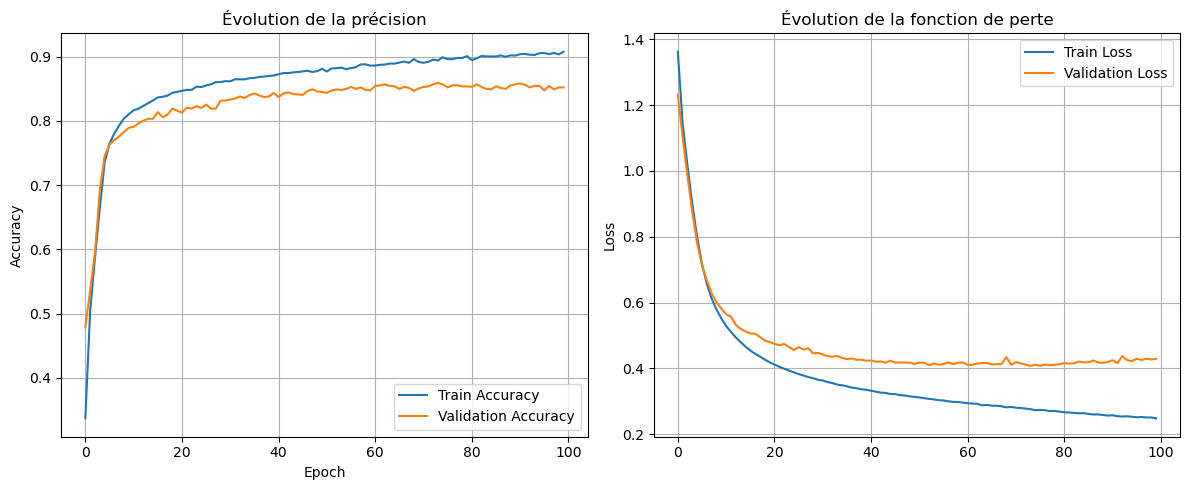

In [31]:

test_loss, test_acc = model6.evaluate(X_test_scaled_simple, y_test_simple)
print(f"Test accuracy: {test_acc:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de la précision")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
print(f"Test accuracy: {test_acc:.2f}")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


L'ajout des dropouts à un effet minime mais il permet quand même d'améliorer le modèle.

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


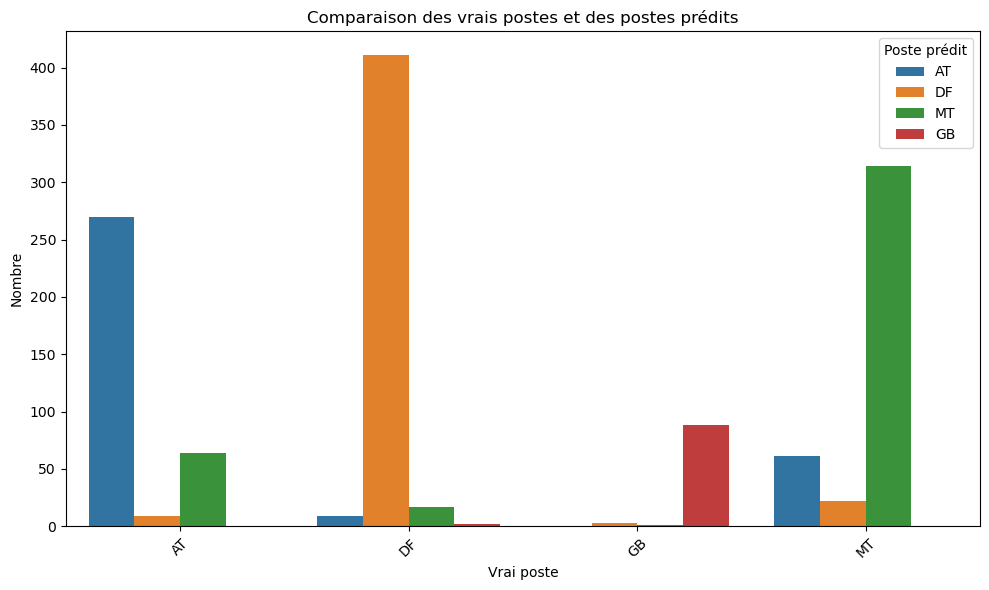

In [32]:
import pandas as pd
import seaborn as sns
 #1. Génération des prédictions
y_pred_probs = model6.predict(X_test_scaled_simple)
y_pred = np.argmax(y_pred_probs, axis=1)

# Récupération des vraies et des prédictions (avec labels)
y_true_labels = label_encoder.inverse_transform(y_test2_simple)
y_pred_labels = label_encoder.inverse_transform(y_pred)

df_results = pd.DataFrame({
    "Vrai poste": y_true_labels,
    "Poste prédit": y_pred_labels
})

# Comptage des combinaisons
counts = df_results.groupby(["Vrai poste", "Poste prédit"]).size().reset_index(name="Nombre")

plt.figure(figsize=(10, 6))
sns.barplot(data=counts, x="Vrai poste", y="Nombre", hue="Poste prédit")
plt.title("Comparaison des vrais postes et des postes prédits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


On remarque que notre modèle reconnaît de manière très satisfaisante les postes lorsque les joueurs sont répartis en 4 postes différents. On cherche maintenant à affiner nos résultats en améliorant le modèle pour les 10 postes proposés initialement.


## Modèle MLP pour 10 postes

### Séparation en données de test/entraineemnt 

In [33]:
# Sélection des features numériques et suppression des lignes incomplètes
X = df2.select_dtypes(include=["number"]).dropna()

# Cible : "Pos" (correspondance avec les lignes de X conservées)
y = df2.loc[X.index, "Pos"]

# Encodage des labels en entiers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Séparation en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 🌟 Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Modèle 7 : Reprends le modèle 5 mais appliqué pour 10 classes

In [34]:
model7 = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)), 
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(10, activation='softmax') 
    
])
model7.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │         2,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,738 (10.70 KB)

 Trainable params: 2,738 (10.70 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model7.compile(
    optimizer='sgd',
    loss='SparseCategoricalCrossentropy', 
    metrics=['accuracy']
)

history = model7.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2234 - loss: 2.2163 - val_accuracy: 0.3163 - val_loss: 2.0206
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3410 - loss: 1.9632 - val_accuracy: 0.3879 - val_loss: 1.8306
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3931 - loss: 1.7645 - val_accuracy: 0.4304 - val_loss: 1.6249
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4477 - loss: 1.5802 - val_accuracy: 0.4634 - val_loss: 1.4747
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4801 - loss: 1.4257 - val_accuracy: 0.5012 - val_loss: 1.3795
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5081 - loss: 1.3627 - val_accuracy: 0.5224 - val_loss: 1.3151
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5420 - loss: 1.2961 - val_accuracy: 0.5460 - val_loss: 1.2639
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5602 - loss: 1.2275 - val_accu

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6598 - loss: 0.9288
Test accuracy: 0.68
Test accuracy: 0.68


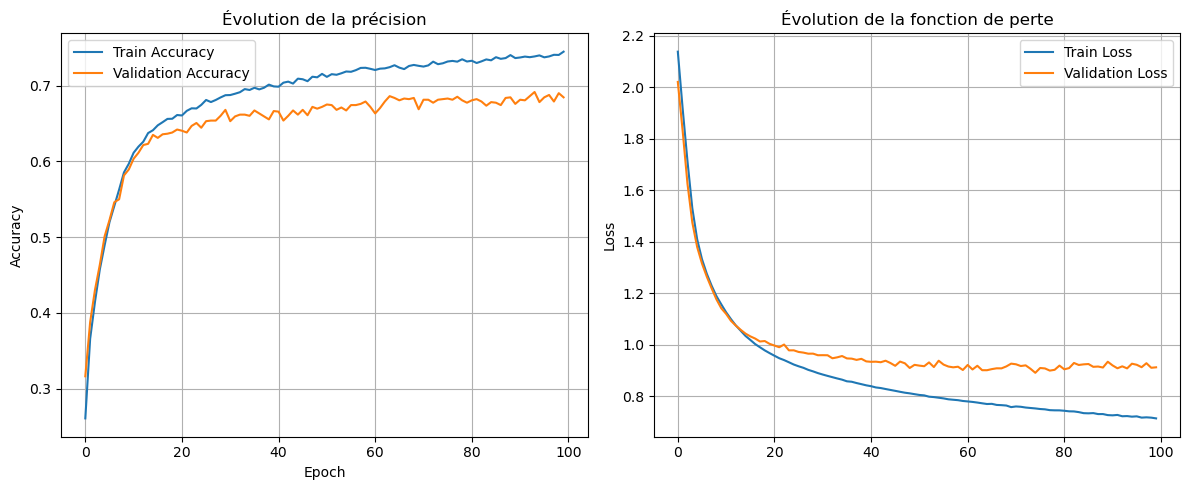

In [36]:
test_loss, test_acc = model7.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {test_acc:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de la précision")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
print(f"Test accuracy: {test_acc:.2f}")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


On a commencé par un modèle simple qui fonctionne correctement mais manque de précision : il faut donc rajouter des neurones pour affiner l'entrainement et rajouter des dropouts afin de limiter le surapprentissage.

### Modèle 8 : plus de neurones et dropout

In [37]:
model8 = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # entrée = nb de features
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
    
])
model8.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,458 (48.66 KB)

 Trainable params: 12,458 (48.66 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model8.compile(
    optimizer='sgd',
    loss='SparseCategoricalCrossentropy',
    metrics=['accuracy']
)

history = model8.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1647 - loss: 2.4049 - val_accuracy: 0.4327 - val_loss: 1.6894
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3883 - loss: 1.7469 - val_accuracy: 0.5303 - val_loss: 1.4676
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4418 - loss: 1.5917 - val_accuracy: 0.5555 - val_loss: 1.3637
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4957 - loss: 1.4328 - val_accuracy: 0.5791 - val_loss: 1.2939
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5145 - loss: 1.4174 - val_accuracy: 0.6003 - val_loss: 1.2426
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5288 - loss: 1.3534 - val_accuracy: 0.6113 - val_loss: 1.2043
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5515 - loss: 1.3202 - val_accuracy: 0.6145 - val_loss: 1.1708
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5630 - loss: 1.2705 - val_accu

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6821 - loss: 0.8727
Test accuracy: 0.69
Test accuracy: 0.69


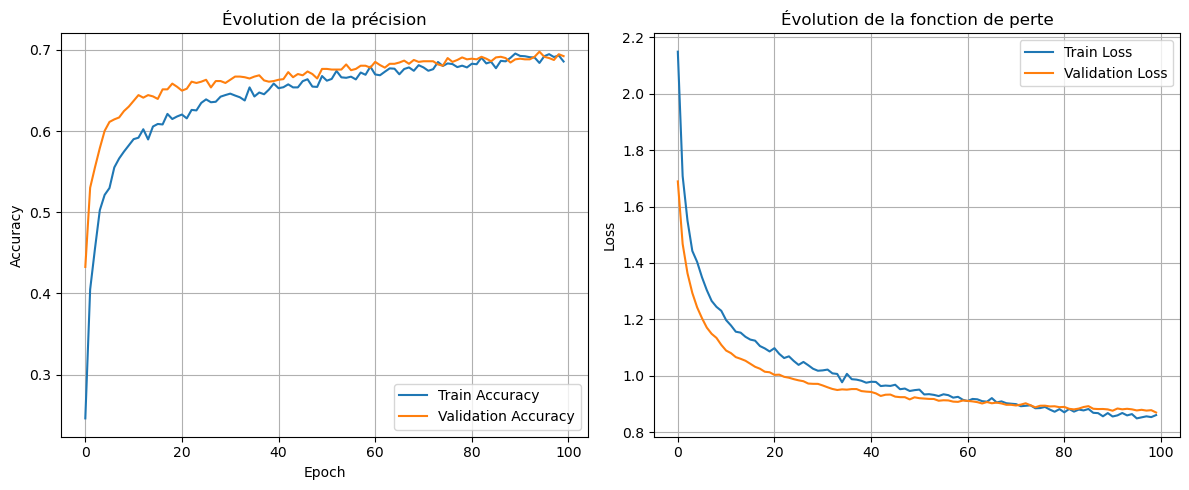

In [39]:
test_loss, test_acc = model8.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {test_acc:.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de la précision")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
print(f"Test accuracy: {test_acc:.2f}")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Le réseau précédant fonctionnait mais manquait de précision. Pour remédier à ce problème on rajoute des neurones sur les couches pour avoir une meilleure capacité d'apprentissage. Seuelement on retombe dans le cas du surapprentissage. On est alors coincé entre limitation d'apprentissage et suraprentissage. C'est pour cela que l'on intègre des dropouts dans le modèle : on désactive aléatoirement certains neurones pendant l'apprentissage. On n'arrive pas vraiment à etre plus précis qu'avec le premier modèle. 

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


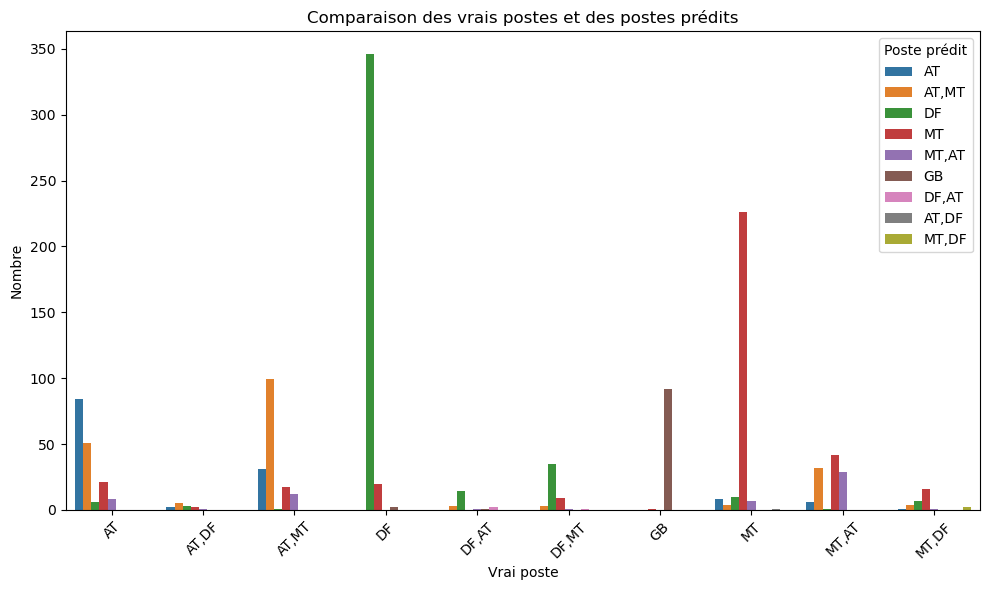

In [40]:
import pandas as pd
import seaborn as sns
 #1. Génération des prédictions
y_pred_probs = model8.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Récupération des vraies et des prédictions (avec labels)
y_true_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

df_results = pd.DataFrame({
    "Vrai poste": y_true_labels,
    "Poste prédit": y_pred_labels
})

# Comptage des combinaisons
counts = df_results.groupby(["Vrai poste", "Poste prédit"]).size().reset_index(name="Nombre")

plt.figure(figsize=(10, 6))
sns.barplot(data=counts, x="Vrai poste", y="Nombre", hue="Poste prédit")
plt.title("Comparaison des vrais postes et des postes prédits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Autoencodeur et Clustering

### 10 classes 

In [41]:
input_dim = X.shape[1]

# Création de l'encodeur
input_layer = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(input_layer)
x = layers.Dense(32, activation='relu')(x)
latent = layers.Dense(2, activation='linear', name='latent')(x)  # --> Espace latent en 2 dimension  

# Création du décodeur
x = layers.Dense(32, activation='relu')(latent)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs=input_layer, outputs=output)
autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()
# Entraînement du modèle
autoencoder.fit(X, X, epochs=100, batch_size=32, validation_split=0.2, shuffle=True)

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 156)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 156)            │        10,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,542 (95.87 KB)

 Trainable params: 24,542 (95.87 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 324910.1875 - val_loss: 48770.6094
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18510.1797 - val_loss: 30045.7188
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10475.7295 - val_loss: 19044.6523
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7939.2515 - val_loss: 16629.4688
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6144.1021 - val_loss: 15040.9502
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5206.9077 - val_loss: 14787.0664
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4953.6392 - val_loss: 14617.2998
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4744.0278 - val_loss: 14586.7959
Epoch 9/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4833.1704 - val_loss: 14914.5869
Epoch 10/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4680.2476 - val_loss: 14413.5781
Epoch 11/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

In [ ]:
# Extraction des embeddings

encoder = Model(inputs=input_layer, outputs=latent)
embeddings = encoder.predict(X)

# Réalisation du cluster avec la méthode des k moyens

k = 10  # nombre de clusters que l'on veut 
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# Évaluation 

silhouette = silhouette_score(embeddings, cluster_labels)
ari = adjusted_rand_score(y_encoded, cluster_labels)

print(f"Silhouette Score : {silhouette:.3f}")
print(f"ARI (Adjusted Rand Index) : {ari:.3f}")


199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Silhouette Score : 0.499
ARI (Adjusted Rand Index) : 0.014


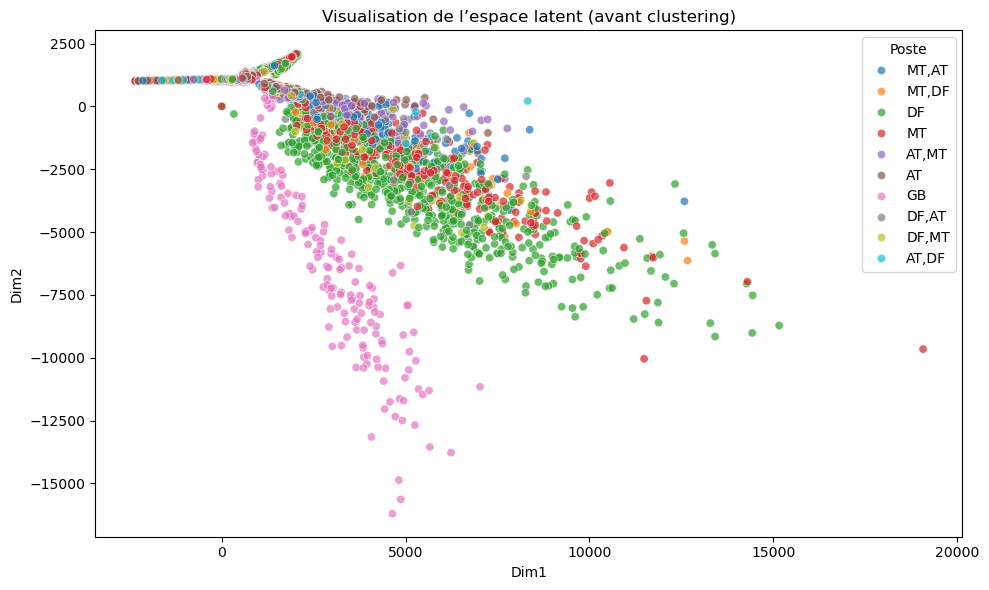

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Récupération des labels réels pour affichage
labels_reels = label_encoder.inverse_transform(y_encoded)

# Création d’un DataFrame pour faciliter la visualisation
df_embed = pd.DataFrame(embeddings, columns=["Dim1", "Dim2"])
df_embed["Poste"] = labels_reels

# Affichage
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_embed,
    x="Dim1", y="Dim2",
    hue="Poste",
    palette="tab10",
    alpha=0.7
)
plt.title("Visualisation de l’espace latent (avant clustering)")
plt.legend(title="Poste")
plt.tight_layout()
plt.show()


In [44]:
# Transformation inverse des postes (entiers → noms)
noms = df2.loc[X.index, "Joueur"]
postes_reels = label_encoder.inverse_transform(y_encoded)

df_visu = pd.DataFrame({
    "x": embeddings[:, 0],
    "y": embeddings[:, 1],
    "Poste réel": postes_reels,
    "Cluster KMeans": cluster_labels.astype(str), 
    "Joueur": noms.values
})

fig2 = px.scatter(
    df_visu, x="x", y="y",
    color="Cluster KMeans",
    hover_name="Joueur",
    title="Embeddings 2D - Couleur par Cluster K-Means",
    width=800, height=600
)
fig2.update_traces(marker=dict(size=7, opacity=0.8))
fig2.show()

In [45]:
import plotly.express as px
import pandas as pd

# Transformation inverse pour retrouver les noms de postes
postes_reels = label_encoder.inverse_transform(y_encoded)

# Table de correspondance cluster ↔ poste
df_cluster_poste = pd.DataFrame({
    "Cluster": cluster_labels,
    "Poste": postes_reels
})

# Table de contingence brute
contingence = pd.crosstab(df_cluster_poste["Cluster"], df_cluster_poste["Poste"])

# Table de proportions (chaque ligne = 1 cluster)
contingence_prop = contingence.div(contingence.sum(axis=1), axis=0)

# Mise au format long pour Plotly
df_long = contingence_prop.reset_index().melt(
    id_vars="Cluster", 
    var_name="Poste", 
    value_name="Proportion"
)

# Graphique en barres empilées
fig_bar = px.bar(
    df_long,
    x="Cluster",
    y="Proportion",
    color="Poste",
    title="Répartition des postes réels par cluster K-Means",
    barmode="stack",
    text_auto=".1%"  # pourcentages sur les barres
)

fig_bar.update_layout(
    xaxis_title="Cluster KMeans",
    yaxis_title="Proportion de joueurs",
    width=800,
    height=600
)

fig_bar.show()


### Conclusion

Le clustering appliqué sur les embeddings 2D des joueurs met en évidence un point important : les profils statistiques des joueurs ne correspondent pas toujours de manière stricte à leur poste officiel. En d'autres termes, des joueurs occupant un même poste peuvent présenter des caractéristiques très différentes, tandis que certains joueurs de postes distincts peuvent, au contraire, avoir des profils similaires.

Ce constat permet d'expliquer en partie la précision limitée (environ 70%) obtenue par nos réseaux de neurones lors de la prédiction des postes à partir des statistiques. Le modèle se heurte en effet à une ambiguïté structurelle : les données ne permettent pas toujours de distinguer clairement les postes. Par exemple, un latéral offensif peut statistiquement ressembler à un ailier, rendant la classification plus complexe.

Ainsi, les résultats du clustering confirment que le poste ne détermine pas entièrement le profil d’un joueur, ce qui remet en question la pertinence d’une classification strictement fondée sur les postes traditionnels à partir de données statistiques seules.